# Predicting Employee Attrition Using Machine Learning

This portfolio notebook consolidates two stages of an employee-attrition analysis into one end-to-end case study. The first stage established a **logistic-regression baseline model** using a limited feature set. The second stage expanded the analysis through exploratory data analysis (EDA), feature engineering, one-hot encoding, and comparison of **Random Forest** and **AdaBoost** classifiers.

The business goal is to evaluate whether historical workforce characteristics can help identify employees at greater risk of attrition and to interpret model tradeoffs in a way that supports HR decision-making.

## Analytical Question

**Can historical workforce characteristics help identify employees who may be at greater risk of attrition?**

A secondary question is whether different model-performance tradeoffs are more useful for different HR priorities—for example, identifying a broader share of potentially at-risk employees versus limiting false-positive predictions.

## Data Availability and Reproducibility

The original analysis used two HR datasets supplied through university coursework and merged them on `EmployeeNumber`. Because no explicit redistribution license was provided, the raw course datasets are **not included** in the public portfolio repository.

The notebook therefore uses two layers of reproducibility:

1. **Original workflow code** is preserved so the analysis can be rerun in an authorized environment containing the course data.
2. **Aggregate summaries and original reported model metrics** are included so the portfolio version remains readable and executable without redistributing row-level source data.

The model metrics shown in this notebook preserve the outputs from the original executed coursework notebooks rather than silently replacing them with results from a different software environment.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Expected paths if the original course data are available locally.
DATA_DIR = Path("../data")
HR1_PATH = DATA_DIR / "HRData1.csv"
HR2_PATH = DATA_DIR / "HRData2.csv"

SOURCE_DATA_AVAILABLE = HR1_PATH.exists() and HR2_PATH.exists()

print(f"Original source files available: {SOURCE_DATA_AVAILABLE}")
if not SOURCE_DATA_AVAILABLE:
    print("Portfolio mode: raw course datasets are not distributed in this repository.")

Original source files available: False
Portfolio mode: raw course datasets are not distributed in this repository.


## 1. Original Data Preparation Workflow

The original project loaded two HR files and performed an inner merge on `EmployeeNumber`. Each source contained 1,470 employee records. The merge produced 1,470 rows and 30 columns.

In [2]:
if SOURCE_DATA_AVAILABLE:
    hr1_df = pd.read_csv(HR1_PATH)
    hr2_df = pd.read_csv(HR2_PATH)

    hr_merged_df = pd.merge(
        hr1_df,
        hr2_df,
        how="inner",
        on="EmployeeNumber"
    )

    print(f"HR 1 data: rows={hr1_df.shape[0]}, cols={hr1_df.shape[1]}")
    print(f"HR 2 data: rows={hr2_df.shape[0]}, cols={hr2_df.shape[1]}")
    print(f"Merged data: rows={hr_merged_df.shape[0]}, cols={hr_merged_df.shape[1]}")
else:
    hr_merged_df = None
    print("Original merge code preserved; source data are unavailable in portfolio mode.")

Original merge code preserved; source data are unavailable in portfolio mode.


### Data Validation

The original work documented the following validation results:

- **1,470 rows** in each source dataset
- **1,470 rows and 30 columns** after the inner merge
- **0 missing values** in the merged dataset
- **0 duplicate rows**
- **0 duplicate `EmployeeNumber` values**

These checks confirmed that the merge preserved one record per employee and did not introduce obvious missingness or duplicate employee identifiers.

In [3]:
validation_summary = pd.DataFrame({
    "Check": [
        "HRData1 rows",
        "HRData2 rows",
        "Merged rows",
        "Merged columns",
        "Missing values",
        "Duplicate rows",
        "Duplicate EmployeeNumber values",
    ],
    "Result": [1470, 1470, 1470, 30, 0, 0, 0]
})

validation_summary

,Check,Result
0,HRData1 rows,1470
1,HRData2 rows,1470
2,Merged rows,1470
3,Merged columns,30
4,Missing values,0
5,Duplicate rows,0
6,Duplicate EmployeeNumber values,0


## 2. Baseline Logistic Regression

The first project stage established a deliberately simple benchmark. A binary `HighIncome` feature was created using **MonthlyIncome > 8,000**, and the model used only:

- `HighIncome`
- `YearsWithCurrManager`

The target was `Attrition`. The data were split **80% training / 20% testing** using `random_state=10`, and a logistic-regression classifier was fit to the training set.

In [4]:
def prepare_baseline_data(df):
    """Prepare the feature set used in the original baseline model."""
    working = df.copy()
    working["HighIncome"] = (working["MonthlyIncome"] > 8000).astype(int)
    return working[["HighIncome", "YearsWithCurrManager", "Attrition"]]

if SOURCE_DATA_AVAILABLE:
    baseline_df = prepare_baseline_data(hr_merged_df)

    X_baseline = baseline_df[["HighIncome", "YearsWithCurrManager"]]
    y_baseline = baseline_df["Attrition"]

    X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
        X_baseline,
        y_baseline,
        test_size=0.20,
        random_state=10
    )

    baseline_model = LogisticRegression()
    baseline_model.fit(X_train_base, y_train_base)

    y_train_base_pred = baseline_model.predict(X_train_base)
    y_test_base_pred = baseline_model.predict(X_test_base)
else:
    print("Baseline training code preserved; original source data are unavailable in portfolio mode.")

Baseline training code preserved; original source data are unavailable in portfolio mode.


### Baseline Performance

The baseline model provided a useful benchmark but had limited precision and recall on the test set. In particular, recall of approximately 29% meant that it identified fewer than one-third of the employees who experienced attrition in the test sample.

In [5]:
baseline_metrics = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [0.7270408163, 0.6666666667],
    "Precision": [0.4915966387, 0.4032258065],
    "Recall": [0.3690851735, 0.2906976744],
})

baseline_metrics.style.format({
    "Accuracy": "{:.1%}",
    "Precision": "{:.1%}",
    "Recall": "{:.1%}"
})

,Dataset,Accuracy,Precision,Recall
0,Training,72.7%,49.2%,36.9%
1,Testing,66.7%,40.3%,29.1%


## 3. Exploratory Data Analysis

The second project stage expanded the analysis before building more advanced classifiers. The EDA examined the overall attrition rate and workforce characteristics such as monthly income and years at the company.

The original dataset contained **1,067 employees who stayed** and **403 employees who left**, corresponding to an attrition rate of approximately **27.4%**.

In [6]:
attrition_summary = pd.DataFrame({
    "Status": ["Stayed", "Left"],
    "Count": [1067, 403],
})
attrition_summary["Percent"] = attrition_summary["Count"] / attrition_summary["Count"].sum()
attrition_summary

,Status,Count,Percent
0,Stayed,1067,0.72585
1,Left,403,0.27415


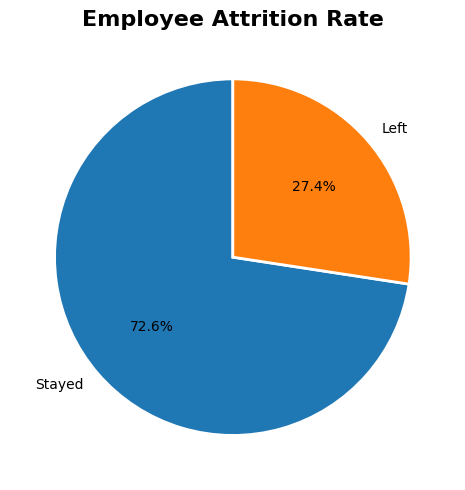

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(
    attrition_summary["Count"],
    labels=attrition_summary["Status"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title("Employee Attrition Rate", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Monthly Income by Attrition

Employees who left showed a wider monthly-income distribution than employees who stayed, although the distributions overlapped substantially. This supports treating income as one potentially useful predictor rather than a stand-alone explanation of attrition.

The boxplot below is reconstructed from aggregate distribution statistics from the original analysis so that the public notebook does not require row-level course data.

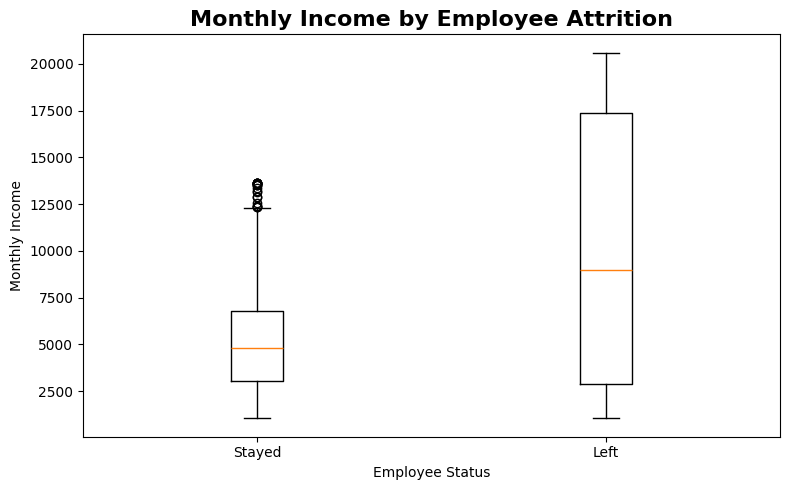

In [8]:
income_box_stats = [
    {
        "label": "Stayed",
        "q1": 3030.0,
        "med": 4822.0,
        "q3": 6757.0,
        "whislo": 1083.0,
        "whishi": 12316.0,
        "fliers": [
            12354, 12356, 12392, 12423, 12551, 12865, 12879, 13124,
            13192, 13354, 13509, 13514, 13536, 13587, 13602, 13608,
            13622, 13634, 13642, 13644
        ],
    },
    {
        "label": "Left",
        "q1": 2874.0,
        "med": 8984.0,
        "q3": 17370.0,
        "whislo": 1039.0,
        "whishi": 20599.0,
        "fliers": [],
    },
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(income_box_stats, showfliers=True)
ax.set_title("Monthly Income by Employee Attrition", fontsize=16, fontweight="bold")
ax.set_xlabel("Employee Status")
ax.set_ylabel("Monthly Income")
plt.tight_layout()
plt.show()

### Years at Company by Attrition

Years at the company also showed considerable overlap between employees who stayed and employees who left. The medians were similar, while the group that left showed a wider upper range. Tenure alone therefore did not clearly separate the two attrition outcomes.

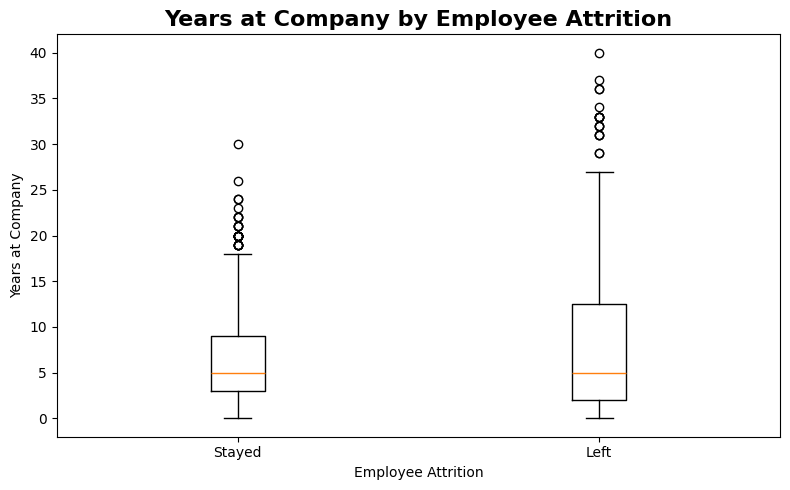

In [9]:
years_box_stats = [
    {
        "label": "Stayed",
        "q1": 3.0,
        "med": 5.0,
        "q3": 9.0,
        "whislo": 0.0,
        "whishi": 18.0,
        "fliers": [
            19, 19, 19, 19, 19, 19,
            20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
            21, 21, 21, 21, 22, 22, 22, 23, 24, 24, 26, 30
        ],
    },
    {
        "label": "Left",
        "q1": 2.0,
        "med": 5.0,
        "q3": 12.5,
        "whislo": 0.0,
        "whishi": 27.0,
        "fliers": [29, 29, 31, 31, 31, 32, 32, 32, 33, 33, 33, 33, 33, 34, 36, 36, 37, 40],
    },
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bxp(years_box_stats, showfliers=True)
ax.set_title("Years at Company by Employee Attrition", fontsize=16, fontweight="bold")
ax.set_xlabel("Employee Attrition")
ax.set_ylabel("Years at Company")
plt.tight_layout()
plt.show()

## 4. Expanded Feature Engineering

The second project stage broadened the model input beyond the two-variable baseline. Two engineered features were created:

- `high_income = 1` when **MonthlyIncome ≥ 7,000**
- `Tenured = 1` when **YearsAtCompany ≥ 11**

The change from the baseline income threshold (>8,000) to the later threshold (≥7,000) is preserved because that is how the two original project stages were implemented.

The expanded model used numeric workforce characteristics along with categorical fields for **Gender, MaritalStatus, JobRole, and Department**.

In [10]:
def prepare_ensemble_features(df):
    """Reproduce the feature-engineering workflow used in Project Two."""
    working = df.copy()

    working["high_income"] = (working["MonthlyIncome"] >= 7000).astype(int)
    working["Tenured"] = (working["YearsAtCompany"] >= 11).astype(int)

    selected_columns = [
        "Age",
        "Attrition",
        "Department",
        "Education",
        "Gender",
        "high_income",
        "JobRole",
        "JobSatisfaction",
        "MaritalStatus",
        "MonthlyIncome",
        "NumCompaniesWorked",
        "PerformanceRating",
        "StockOptionLevel",
        "Tenured",
        "TotalWorkingYears",
        "TrainingTimesLastYear",
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsWithCurrManager",
    ]

    model_data = working[selected_columns].copy()
    categorical_columns = ["Gender", "MaritalStatus", "JobRole", "Department"]

    # Compatibility across scikit-learn versions.
    try:
        encoder = OneHotEncoder(sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(sparse=False)

    encoded = encoder.fit_transform(model_data[categorical_columns])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(categorical_columns),
        index=model_data.index,
    )

    data_df = pd.concat([model_data, encoded_df], axis=1)
    data_df = data_df.drop(columns=categorical_columns)

    return data_df

if SOURCE_DATA_AVAILABLE:
    data_df = prepare_ensemble_features(hr_merged_df)
    print(f"Encoded data: rows={data_df.shape[0]}, cols={data_df.shape[1]}")
else:
    print("Feature-engineering code preserved; source data are unavailable in portfolio mode.")

Feature-engineering code preserved; source data are unavailable in portfolio mode.


### Encoded Feature Set

The original one-hot encoding step produced **1,470 rows and 32 columns**, including the target variable. This corresponds to **31 predictor columns** after the categorical variables were expanded into indicator columns.

In [11]:
feature_summary = pd.DataFrame({
    "Stage": ["Merged source", "Encoded model data", "Predictor matrix"],
    "Rows": [1470, 1470, 1470],
    "Columns": [30, 32, 31],
})
feature_summary

,Stage,Rows,Columns
0,Merged source,1470,30
1,Encoded model data,1470,32
2,Predictor matrix,1470,31


## 5. Advanced Train/Test Preparation

For the ensemble-model phase, the encoded dataset was split **70% training / 30% testing** using `random_state=40`.

- Training set: **1,029 rows**
- Test set: **441 rows**

In [12]:
if SOURCE_DATA_AVAILABLE:
    target = "Attrition"
    X = data_df.drop(columns=target)
    y = data_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=40,
    )

    print(f"Training set: X={X_train.shape}, y={y_train.shape}")
    print(f"Test set: X={X_test.shape}, y={y_test.shape}")
else:
    split_summary = pd.DataFrame({
        "Dataset": ["Training", "Testing"],
        "Rows": [1029, 441],
        "Predictors": [31, 31],
    })
    display(split_summary)

,Dataset,Rows,Predictors
0,Training,1029,31
1,Testing,441,31


## 6. Random Forest Classifier

The Random Forest model used `GridSearchCV` with two-fold cross-validation to search combinations of:

- `n_estimators`: 250 or 300
- `max_depth`: 5 or 10
- `bootstrap`: True or False
- `class_weight`: balanced

The original test results were approximately **85% accuracy, 84% precision, and 59% recall**.

In [13]:
def fit_random_forest(X_train, y_train):
    model = RandomForestClassifier(random_state=40)
    param_grid = {
        "n_estimators": [250, 300],
        "max_depth": [5, 10],
        "bootstrap": [True, False],
        "class_weight": ["balanced"],
    }

    search = GridSearchCV(model, param_grid, n_jobs=-1, cv=2)
    search.fit(X_train, y_train)
    return search

if SOURCE_DATA_AVAILABLE:
    rf_grid_search = fit_random_forest(X_train, y_train)
    y_rf_train_pred = rf_grid_search.predict(X_train)
    y_rf_test_pred = rf_grid_search.predict(X_test)
else:
    print("Random Forest training code preserved; original source data are unavailable in portfolio mode.")

Random Forest training code preserved; original source data are unavailable in portfolio mode.


## 7. AdaBoost Classifier

The AdaBoost model used `GridSearchCV` with two-fold cross-validation across:

- `n_estimators`: 250 or 300
- `learning_rate`: 0.1, 0.01, or 0.001

The original test results were approximately **85% accuracy, 92% precision, and 55% recall**.

In [14]:
def fit_adaboost(X_train, y_train):
    model = AdaBoostClassifier(random_state=40)
    param_grid = {
        "n_estimators": [250, 300],
        "learning_rate": [0.1, 0.01, 0.001],
    }

    search = GridSearchCV(model, param_grid, n_jobs=-1, cv=2)
    search.fit(X_train, y_train)
    return search

if SOURCE_DATA_AVAILABLE:
    ada_grid_search = fit_adaboost(X_train, y_train)
    y_ada_train_pred = ada_grid_search.predict(X_train)
    y_ada_test_pred = ada_grid_search.predict(X_test)
else:
    print("AdaBoost training code preserved; original source data are unavailable in portfolio mode.")

AdaBoost training code preserved; original source data are unavailable in portfolio mode.


## 8. Model Performance Comparison

The table below preserves the metrics reported in the original executed notebooks.

In [15]:
model_metrics = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Random Forest",
        "AdaBoost",
    ],
    "Test Accuracy": [0.6666666667, 0.85, 0.85],
    "Test Precision": [0.4032258065, 0.84, 0.92],
    "Test Recall": [0.2906976744, 0.59, 0.55],
})

model_metrics.style.format({
    "Test Accuracy": "{:.1%}",
    "Test Precision": "{:.1%}",
    "Test Recall": "{:.1%}",
})

,Model,Test Accuracy,Test Precision,Test Recall
0,Baseline Logistic Regression,66.7%,40.3%,29.1%
1,Random Forest,85.0%,84.0%,59.0%
2,AdaBoost,85.0%,92.0%,55.0%


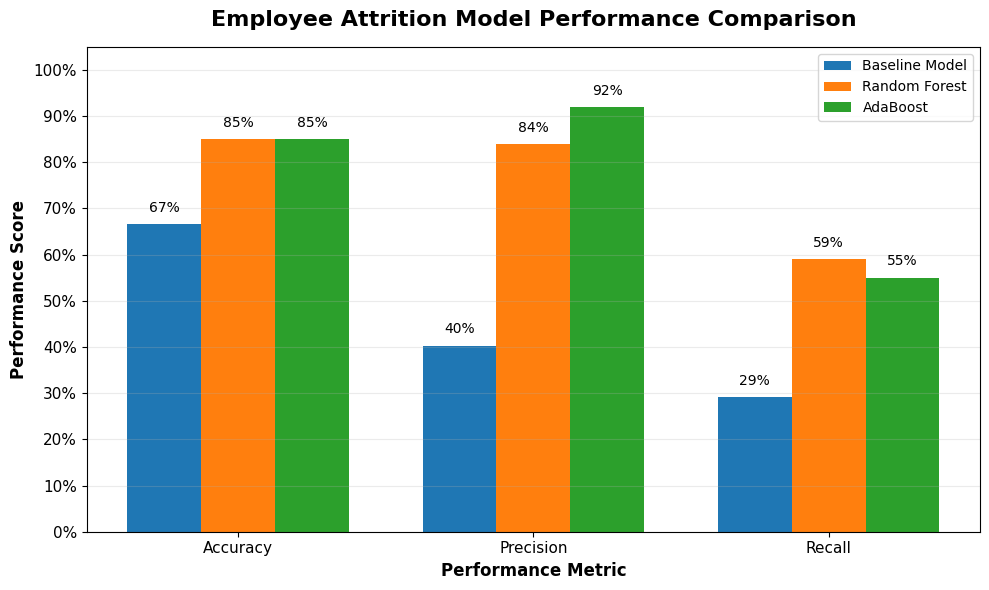

In [16]:
metrics = ["Accuracy", "Precision", "Recall"]
comparison = {
    "Baseline Model": [0.6666666667, 0.4032258065, 0.2906976744],
    "Random Forest": [0.85, 0.84, 0.59],
    "AdaBoost": [0.85, 0.92, 0.55],
}

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (model_name, values) in enumerate(comparison.items()):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=model_name)
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.0%}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

ax.set_title(
    "Employee Attrition Model Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Performance Metric", fontsize=12, fontweight="bold")
ax.set_ylabel("Performance Score", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_yticklabels([f"{value:.0%}" for value in np.arange(0, 1.1, 0.1)])
ax.tick_params(axis="both", labelsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

### Portfolio Comparison Note

The baseline and ensemble results show a clear progression in the coursework, but they are **not a strictly controlled head-to-head experiment**. The two stages used different feature sets, different income-threshold definitions, and different train/test splits (`80/20, random_state=10` for the baseline versus `70/30, random_state=40` for the ensemble models).

For that reason, the comparison is best interpreted as a **directional project progression** rather than as a formal estimate of how much performance improved solely because of the modeling algorithm.

## 9. Business Interpretation

Both ensemble models achieved approximately 85% test accuracy, but their precision-recall tradeoffs differed:

- **Random Forest** achieved the stronger recall (about **59%**), making it more useful when the priority is identifying a broader share of employees who may be at risk of leaving.
- **AdaBoost** achieved the stronger precision (about **92%**), making it more useful when the priority is limiting false positives and targeting retention resources more selectively.

This is why accuracy alone is not sufficient for model selection. The appropriate model depends on the organization's retention priorities and the costs associated with missed cases versus unnecessary interventions.

Model predictions should be treated as **decision support**, not as automated employment decisions.

## 10. Limitations and Future Improvements

### Analytical Limitations

- The public repository does not redistribute the row-level course datasets, so the complete model-training workflow requires authorized access to the original files.
- The attrition outcome is imbalanced (approximately 27.4% left versus 72.6% stayed), making precision and recall especially important alongside accuracy.
- The baseline and ensemble stages used different feature sets and train/test splits, so cross-stage metric comparisons are directional rather than strictly controlled.
- The original ensemble workflow used two-fold cross-validation during grid search; a future version could evaluate model stability with a more extensive validation strategy.
- Predictive associations do not establish causal drivers of employee turnover.

### Professional Deployment Consideration

The original coursework model included demographic fields such as `Gender` and `MaritalStatus`. Any real-world HR use would require appropriate fairness, legal, privacy, and governance review before such variables were used in employment-related decision support. A production system should also monitor model drift and subgroup performance over time.

## 11. Downstream Reporting

The original Project Two workflow exported train/test predictions for use in a Power BI dashboard. Those row-level prediction files and the editable PBIX file are not included in the public portfolio because they may contain or embed course-provided data.

Portfolio-facing exports can instead communicate the EDA findings, model-performance comparison, and HR decision tradeoffs without redistributing the underlying source records.

## Portfolio Note

This notebook is a consolidated, cleaned portfolio version of two DAT 430 coursework projects. Classroom instructions, redundant validation cells, assignment-specific scaffolding, and raw-data export steps were removed or consolidated while preserving the original analytical sequence and reported model results.

The resulting case study emphasizes the progression from a simple baseline model to richer feature engineering, ensemble classification, model evaluation, and business-focused interpretation.